In [56]:
import numpy as np
from keras.initializers import RandomNormal
from keras.layers import Input, Activation, Dense, Dropout, Flatten, ReLU
from keras.models import Model
# from keras.models import Input
from keras.optimizers import Adam
from keras.utils import to_categorical, plot_model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [57]:
# load dataset
(x_train, y_train),(x_test, y_test) = mnist.load_data()

print(x_train.shape , x_test.shape)

(60000, 28, 28) (10000, 28, 28)


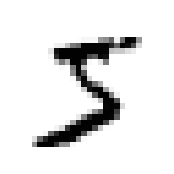

In [58]:
plt.figure(figsize=(2,2))   # 2 * 2 inches,  1 inch - 80 pixels
plt.axis("off")
plt.imshow(x_train[0], cmap='Greys')

In [18]:
# collect specific digits

# train_filter = np.where((y_train==0) | (y_train==4))
# test_filter = np.where((y_test==0) | (y_test==4))

# X_train, Y_train = X_train[train_filter], Y_train[train_filter]
# X_test, Y_test = X_test[test_filter], Y_test[test_filter]


(array([5923., 6742., 5958., 6131., 5842., 5421., 5918., 6265., 5851.,
        5949.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

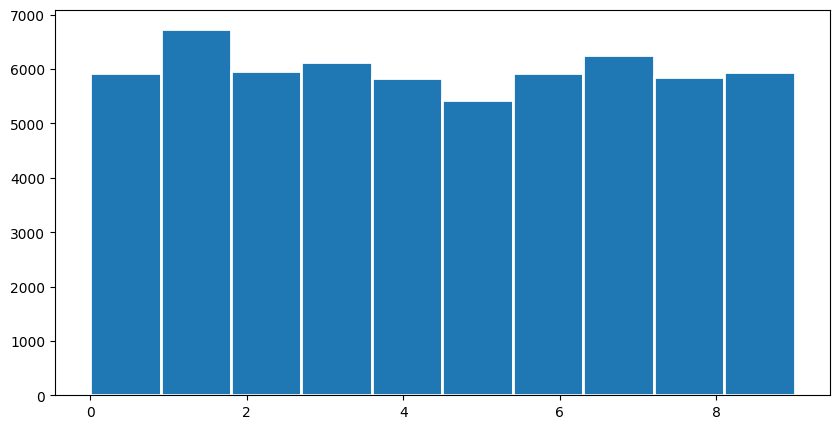

In [59]:
plt.figure(figsize=(10,5))
plt.hist(y_train, edgecolor="white" , linewidth=2)


In [60]:
# Row Labels

print(y_train[:10])

[5 0 4 1 9 2 1 3 1 4]


In [28]:
# one-hot encoded labels (compare above)

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print(y_train_cat[:10])


[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


## Dataset Normalization

In [31]:
# normalization
x_train_reg = x_train.astype('float32') / 255.0
x_test_reg = x_test.astype('float32') / 255.0



## Classifier Architecture

In [ ]:
def define_classifier(image_shape):

    init = RandomNormal(stddev=0.02)
    in_image = Input(shape=image_shape)

    c = Flatten()(in_image)

    c = Dense(16, activation='relu', kernel_initializer=init)(c)
    c = Dropout(0.1)(c)

    c = Dense(32, activation='relu', kernel_initializer=init)(c)
    c = Dropout(0.1)(c)

    c = Dense(64, activation='relu', kernel_initializer=init)(c)
    c = Dropout(0.1)(c)

    out = Dense(10, activation = 'softmax', kernel_initializer=init)(c)

    model = Model(in_image , out)
    model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

    return model



In [35]:
model = define_classifier((28,28,1))
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,866 (61.98 KB)

 Trainable params: 15,866 (61.98 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Model

In [36]:
model.fit(x_train_reg, y_train_cat, epochs=10, batch_size=64)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1114 - loss: 2.3018
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1124 - loss: 2.3013
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1124 - loss: 2.3012
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1124 - loss: 2.3011
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1124 - loss: 2.3011
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1124 - loss: 2.3010
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1124 - loss: 2.3010
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1124 - loss: 2.3009
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1124 - loss: 2.3007
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1124 - loss: 2.3003


In [40]:
# input1 = np.reshape(x_test_reg[7],(1,28,28,1))
# out = model.predict(input1)
# plt.imshow(x_test_reg[7], cmap='Greys')
# print(np.argmin(out))

## Mk.2

In [ ]:
def define_classifier(image_shape):

    init = RandomNormal(stddev=0.02)
    in_image = Input(shape=image_shape)

    c = Flatten()(in_image)

    c = Dense(16, activation='relu', kernel_initializer=init)(c)
    c = Dropout(0.1)(c)


    c = Dense(32, activation='relu', kernel_initializer=init)(c)
    c = Dropout(0.1)(c)

    c = Dense(64, activation='relu', kernel_initializer=init)(c)
    c = Dropout(0.1)(c)

    c = Dense(128, activation='relu', kernel_initializer=init)(c)
    c = Dropout(0.2)(c)

    c = Dense(256, activation='relu', kernel_initializer=init)(c)
    c = Dropout(0.3)(c)

    out = Dense(10, activation = 'softmax', kernel_initializer=init)(c)

    model = Model(in_image , out)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

In [64]:
model = define_classifier((28,28,1))
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,130 (230.98 KB)

 Trainable params: 59,130 (230.98 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model.fit(x_train_reg, y_train_cat, epochs=10, batch_size=64)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1120 - loss: 2.3019
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1124 - loss: 2.3013
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1124 - loss: 2.3012
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1124 - loss: 2.3012
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1124 - loss: 2.3012
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1124 - loss: 2.3012
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1124 - loss: 2.3012
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1124 - loss: 2.3012
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1124 - loss: 2.3012
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1124 - loss: 2.3012


## Mk.3

In [65]:
model.fit(x_train_reg, y_train_cat, epochs=20, batch_size=64)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4777 - loss: 1.2934
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7852 - loss: 0.6842
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8490 - loss: 0.5294
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8791 - loss: 0.4329
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8924 - loss: 0.3874
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8982 - loss: 0.3652
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9024 - loss: 0.3503
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9068 - loss: 0.3276
Epoch 9/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9086 - loss: 0.3220
Epoch 10/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9108 - loss: 0.3143
Epoch 11/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9145 - loss: 0.3035
Epoch 12/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step